## 1. Project setup

Run this notebook from the repository root, or keep it inside `notebooks/` and run the setup cell below. It adds the project root to `sys.path` so imports from `src/` work locally.


In [1]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "src").exists() else NOTEBOOK_DIR.parent

if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError(f"Could not find src/ from current directory: {NOTEBOOK_DIR}")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("src exists:", (PROJECT_ROOT / "src").exists())


Project root: d:\UWE\3rd Year\2nd semester\advanced_ai\ai_system
src exists: True


## 2. Imports and configuration


In [2]:
import sys
from pathlib import Path

print("Python executable:", sys.executable)
print("Current working directory:", Path.cwd())

Python executable: d:\UWE\3rd Year\2nd semester\advanced_ai\ai_system\.venv\Scripts\python.exe
Current working directory: d:\UWE\3rd Year\2nd semester\advanced_ai\ai_system\notebooks


In [3]:
import json
import os
from pathlib import Path

# Force KaggleHub to use this project's data/raw folder on drive D instead of the default user cache.
KAGGLEHUB_CACHE_DIR = PROJECT_ROOT / "data" / "raw" / "kagglehub"
KAGGLEHUB_CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ["KAGGLEHUB_CACHE"] = str(KAGGLEHUB_CACHE_DIR)

import kagglehub
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

from src.config import (
    CLASS_NAMES_PATH,
    DATASET_SLUG,
    NUM_CLASSES,
    OUTPUTS_DIR,
    RANDOM_SEED,
    GROUPED_SPLITS_DIR,
)
from src.data.prepare_dataset import (
    build_image_dataframe,
    find_dataset_root,
    save_class_names,
    save_split_csvs,
    stratified_split_dataframe,
    add_source_image_id,
    audit_source_image_overlap,
    grouped_stratified_split_dataframe,
)
from src.data.dataloaders import build_class_name_mapping

plt.style.use("default")
pd.set_option("display.max_rows", 60)
print("KaggleHub cache:", os.environ["KAGGLEHUB_CACHE"])


d:\UWE\3rd Year\2nd semester\advanced_ai\ai_system\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


KaggleHub cache: d:\UWE\3rd Year\2nd semester\advanced_ai\ai_system\data\raw\kagglehub


## 3. Locate or download dataset

Default behavior uses `kagglehub.dataset_download(...)`, which stores the dataset in the local KaggleHub cache. If you have manually downloaded and extracted the dataset, set `LOCAL_DATASET_PATH` to that folder instead.

The full raw dataset must not be committed to Git.


In [4]:
# If you have already extracted the dataset manually, set this to that folder.
# Otherwise leave it as None and KaggleHub will download into data/raw/kagglehub.
LOCAL_DATASET_PATH = None
# Example:
# LOCAL_DATASET_PATH = PROJECT_ROOT / "data" / "raw" / "fruit-and-vegetable-disease-healthy-vs-rotten"

if LOCAL_DATASET_PATH is not None:
    download_path = Path(LOCAL_DATASET_PATH).expanduser().resolve()
else:
    download_path = Path(kagglehub.dataset_download(DATASET_SLUG))

print("Dataset path:", download_path)
print("Dataset path exists:", download_path.exists())


Dataset path: d:\UWE\3rd Year\2nd semester\advanced_ai\ai_system\data\raw\kagglehub\datasets\muhammad0subhan\fruit-and-vegetable-disease-healthy-vs-rotten\versions\1
Dataset path exists: True


## 4. Inspect folder structure

Some dataset downloads contain an extra parent folder before the class folders. The helper below selects the directory whose direct children are class folders.


In [5]:
print("Top-level contents:")
for item in sorted(download_path.iterdir()):
    kind = "dir" if item.is_dir() else "file"
    print(f"{kind:4}  {item.name}")


Top-level contents:
dir   Fruit And Vegetable Diseases Dataset


In [6]:
dataset_root = find_dataset_root(download_path, expected_classes=NUM_CLASSES)
print("Selected dataset root:", dataset_root)

class_dirs = sorted([p for p in dataset_root.iterdir() if p.is_dir()])
print("Class folder count:", len(class_dirs))
for class_dir in class_dirs:
    print(class_dir.name)


Selected dataset root: d:\UWE\3rd Year\2nd semester\advanced_ai\ai_system\data\raw\kagglehub\datasets\muhammad0subhan\fruit-and-vegetable-disease-healthy-vs-rotten\versions\1\Fruit And Vegetable Diseases Dataset
Class folder count: 28
Apple__Healthy
Apple__Rotten
Banana__Healthy
Banana__Rotten
Bellpepper__Healthy
Bellpepper__Rotten
Carrot__Healthy
Carrot__Rotten
Cucumber__Healthy
Cucumber__Rotten
Grape__Healthy
Grape__Rotten
Guava__Healthy
Guava__Rotten
Jujube__Healthy
Jujube__Rotten
Mango__Healthy
Mango__Rotten
Orange__Healthy
Orange__Rotten
Pomegranate__Healthy
Pomegranate__Rotten
Potato__Healthy
Potato__Rotten
Strawberry__Healthy
Strawberry__Rotten
Tomato__Healthy
Tomato__Rotten


## 5. Build image dataframe and validate classes


In [7]:
df = build_image_dataframe(dataset_root)
class_names, class_to_index = build_class_name_mapping(df)
df["class_index"] = df["class_name"].map(class_to_index)

print("Total images:", len(df))
print("Number of classes:", len(class_names))
display(df.head())

assert len(class_names) == NUM_CLASSES, f"Expected {NUM_CLASSES} classes, found {len(class_names)}"
assert df["class_name"].isna().sum() == 0
assert df["image_path"].duplicated().sum() == 0


Total images: 29277
Number of classes: 28


,image_path,relative_path,class_name,class_index
0,d:\UWE\3rd Year\2nd semester\advanced_ai\ai_sy...,Apple__Healthy\FreshApple (1).jpg,Apple__Healthy,0
1,d:\UWE\3rd Year\2nd semester\advanced_ai\ai_sy...,Apple__Healthy\freshApple (1).png,Apple__Healthy,0
2,d:\UWE\3rd Year\2nd semester\advanced_ai\ai_sy...,Apple__Healthy\FreshApple (10).jpg,Apple__Healthy,0
3,d:\UWE\3rd Year\2nd semester\advanced_ai\ai_sy...,Apple__Healthy\FreshApple (100).jpg,Apple__Healthy,0
4,d:\UWE\3rd Year\2nd semester\advanced_ai\ai_sy...,Apple__Healthy\FreshApple (101).jpg,Apple__Healthy,0


In [8]:
print("Class names:")
for idx, name in enumerate(class_names):
    print(f"{idx:02d}: {name}")


Class names:
00: Apple__Healthy
01: Apple__Rotten
02: Banana__Healthy
03: Banana__Rotten
04: Bellpepper__Healthy
05: Bellpepper__Rotten
06: Carrot__Healthy
07: Carrot__Rotten
08: Cucumber__Healthy
09: Cucumber__Rotten
10: Grape__Healthy
11: Grape__Rotten
12: Guava__Healthy
13: Guava__Rotten
14: Jujube__Healthy
15: Jujube__Rotten
16: Mango__Healthy
17: Mango__Rotten
18: Orange__Healthy
19: Orange__Rotten
20: Pomegranate__Healthy
21: Pomegranate__Rotten
22: Potato__Healthy
23: Potato__Rotten
24: Strawberry__Healthy
25: Strawberry__Rotten
26: Tomato__Healthy
27: Tomato__Rotten


## 6. Class balance


In [9]:
counts = df["class_name"].value_counts().sort_index()
summary = counts.rename_axis("class_name").reset_index(name="image_count")
summary["percentage"] = (summary["image_count"] / summary["image_count"].sum() * 100).round(2)
display(summary)

print("Smallest class size:", counts.min())
print("Largest class size:", counts.max())
print("Imbalance ratio:", round(counts.max() / counts.min(), 2))


,class_name,image_count,percentage
0,Apple__Healthy,2438,8.33
1,Apple__Rotten,2925,9.99
2,Banana__Healthy,1999,6.83
3,Banana__Rotten,2797,9.55
4,Bellpepper__Healthy,611,2.09
5,Bellpepper__Rotten,591,2.02
6,Carrot__Healthy,619,2.11
7,Carrot__Rotten,579,1.98
8,Cucumber__Healthy,608,2.08
9,Cucumber__Rotten,593,2.03


Smallest class size: 200
Largest class size: 2925
Imbalance ratio: 14.62


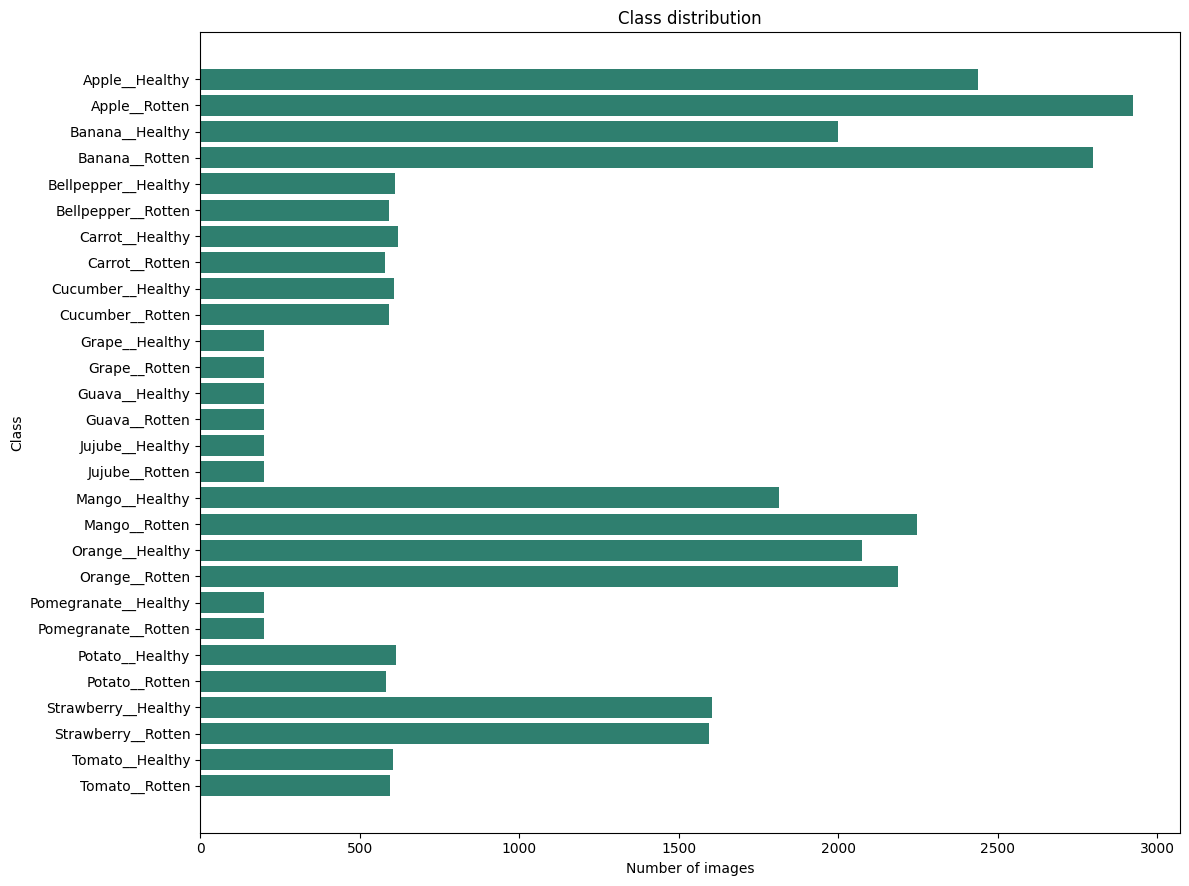

In [10]:
fig_height = max(8, len(counts) * 0.32)
plt.figure(figsize=(12, fig_height))
plt.barh(counts.index, counts.values, color="#2f7f6f")
plt.xlabel("Number of images")
plt.ylabel("Class")
plt.title("Class distribution")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 7. Sample images


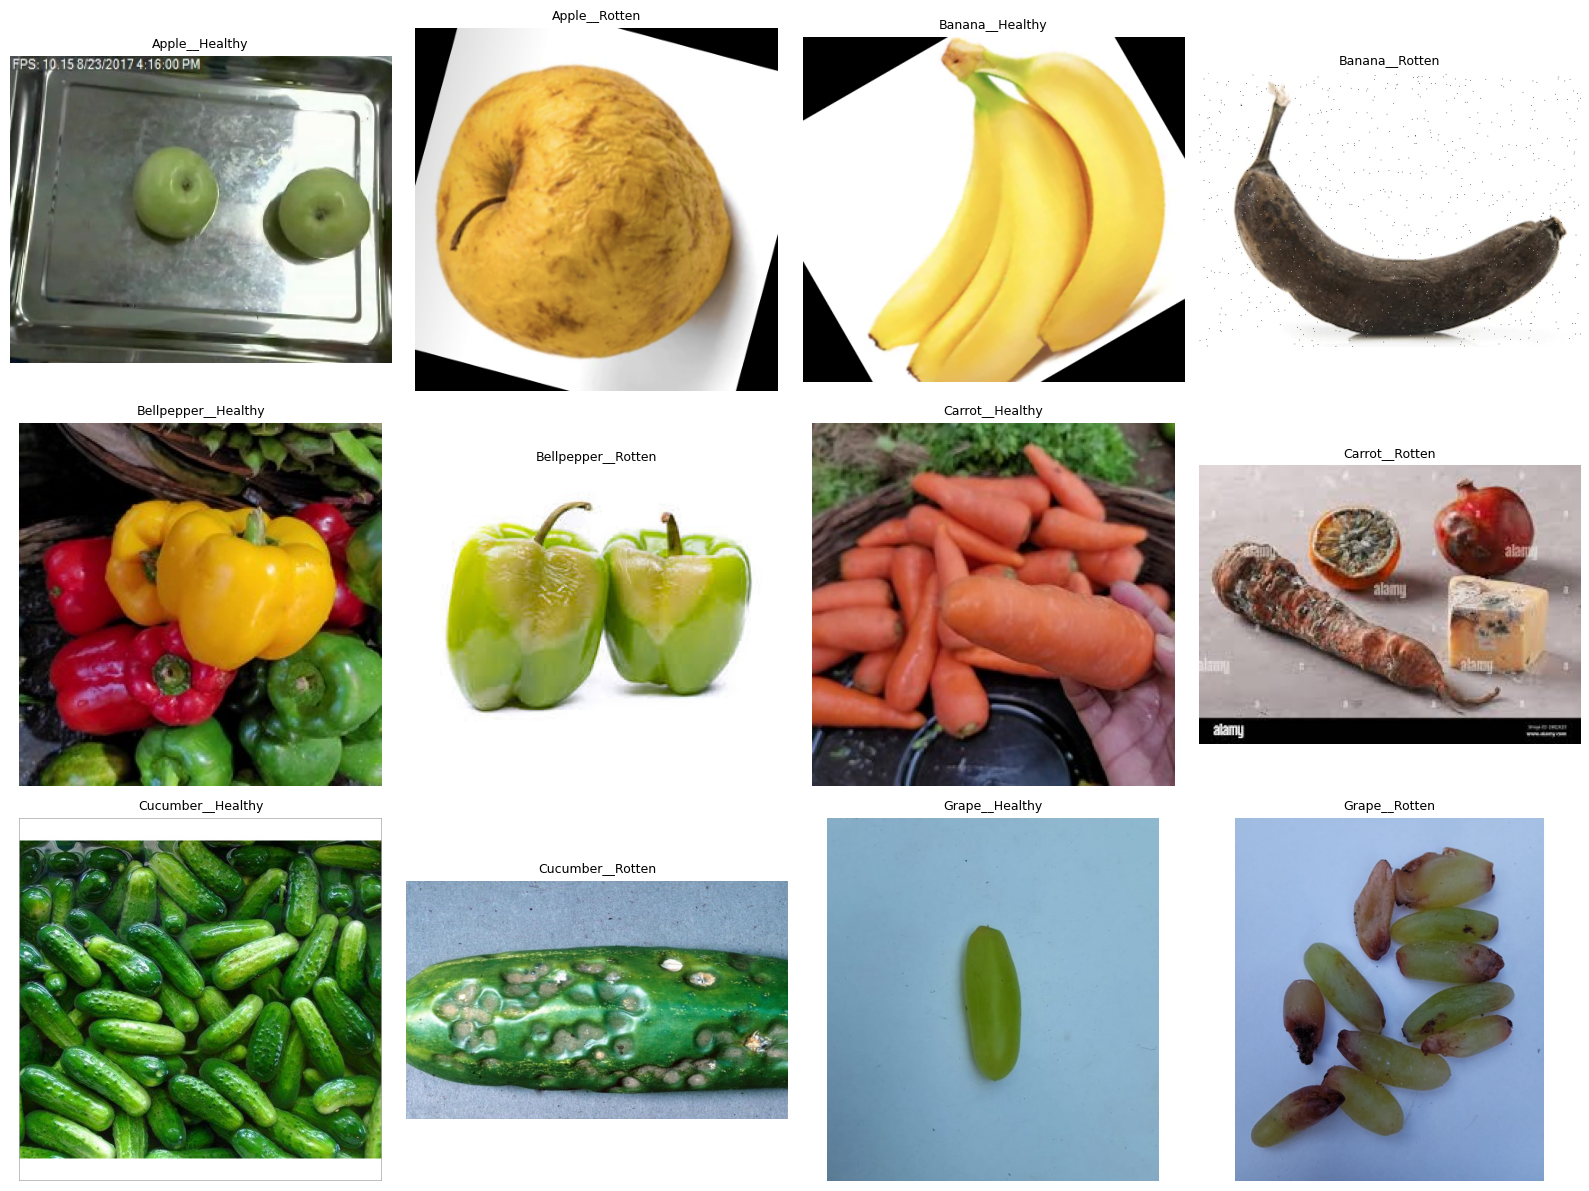

In [11]:
def show_sample_images(dataframe: pd.DataFrame, samples_per_class: int = 1, max_classes: int = 12) -> None:
    selected_classes = sorted(dataframe["class_name"].unique())[:max_classes]
    sampled = (
        dataframe[dataframe["class_name"].isin(selected_classes)]
        .groupby("class_name", group_keys=False)
        .sample(n=samples_per_class, random_state=RANDOM_SEED)
        .reset_index(drop=True)
    )

    n = len(sampled)
    cols = 4
    rows = (n + cols - 1) // cols
    plt.figure(figsize=(cols * 4, rows * 4))

    for i, row in sampled.iterrows():
        image = Image.open(row["image_path"]).convert("RGB")
        ax = plt.subplot(rows, cols, i + 1)
        ax.imshow(image)
        ax.set_title(row["class_name"], fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


show_sample_images(df, samples_per_class=1, max_classes=12)


## 8. Train/validation/test split

The split is stratified by the 28 class labels. The exported CSV files will be used by the local training notebooks.


In [12]:
df = add_source_image_id(df)
train_df, val_df, test_df = grouped_stratified_split_dataframe(df)

print("Split sizes")
print("train:", len(train_df))
print("val:  ", len(val_df))
print("test: ", len(test_df))

split_counts = pd.DataFrame({
    "train": train_df["class_name"].value_counts().sort_index(),
    "val": val_df["class_name"].value_counts().sort_index(),
    "test": test_df["class_name"].value_counts().sort_index(),
}).fillna(0).astype(int)

split_counts["total"] = split_counts.sum(axis=1)
display(split_counts)

assert len(split_counts) == NUM_CLASSES
assert set(train_df["class_name"]) == set(class_names)
assert set(val_df["class_name"]) == set(class_names)
assert set(test_df["class_name"]) == set(class_names)


Split sizes
train: 20493
val:   4392
test:  4392


,train,val,test,total
class_name,,,,
Apple__Healthy,1707,366,365,2438
Apple__Rotten,2047,439,439,2925
Banana__Healthy,1399,300,300,1999
Banana__Rotten,1958,420,419,2797
Bellpepper__Healthy,428,91,92,611
Bellpepper__Rotten,414,88,89,591
Carrot__Healthy,433,93,93,619
Carrot__Rotten,405,87,87,579
Cucumber__Healthy,426,91,91,608


## 9. Export local artifacts

These files are lightweight and useful for reproducibility. The split CSV files contain absolute local image paths plus relative paths.


In [13]:
eda_output_dir = OUTPUTS_DIR / "eda"
eda_output_dir.mkdir(parents=True, exist_ok=True)
GROUPED_SPLITS_DIR.mkdir(parents=True, exist_ok=True)
CLASS_NAMES_PATH.parent.mkdir(parents=True, exist_ok=True)

save_split_csvs(train_df, val_df, test_df, GROUPED_SPLITS_DIR)
summary.to_csv(eda_output_dir / "class_counts.csv", index=False)
split_counts.to_csv(eda_output_dir / "split_counts.csv")
save_class_names(class_names, CLASS_NAMES_PATH)

eda_metadata = {
    "dataset_slug": DATASET_SLUG,
    "download_path": str(download_path),
    "dataset_root": str(dataset_root),
    "num_images": int(len(df)),
    "num_classes": int(len(class_names)),
    "random_seed": RANDOM_SEED,
    "split_sizes": {
        "train": int(len(train_df)),
        "val": int(len(val_df)),
        "test": int(len(test_df)),
    },
}

with open(eda_output_dir / "eda_metadata.json", "w", encoding="utf-8") as f:
    json.dump(eda_metadata, f, indent=2)

print("Saved grouped split CSVs to:", GROUPED_SPLITS_DIR)
print("Saved class names to:", CLASS_NAMES_PATH)
print("Saved EDA outputs to:", eda_output_dir)


Saved split CSVs to: D:\UWE\3rd Year\2nd semester\advanced_ai\ai_system\data\splits
Saved class names to: D:\UWE\3rd Year\2nd semester\advanced_ai\ai_system\models\class_names.json
Saved EDA outputs to: D:\UWE\3rd Year\2nd semester\advanced_ai\ai_system\outputs\eda


## 10. Next step

After this notebook passes, run `02_baseline_cnn.ipynb` locally using `data/splits_grouped/train.csv`, `data/splits_grouped/val.csv`, and `data/splits_grouped/test.csv`. The baseline notebook should import model, dataloader, training, and evaluation helpers from `src/` instead of duplicating core logic.
